In [1]:
# 1. Imports
import sys
import os
import pandas as pd
from IPython.display import display

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import data_loader, features, econometrics, config

target_volatility = 'Sq_Log_Return'

# macro_shocks = ['CPI_Surprise', 'PPI_Surprise', 'FedFunds_Diff'] # The Inflation & Policy Block
# macro_shocks = ['Unemployment_Surprise', 'Housing_Starts_Surprise'] # The Real Economy Block
# macro_shocks = ['Trade_Balance_Surprise', 'M1_Money_Surprise'] # The Global & Liquidity Block
macro_shocks = ['NFP_Surprise', 'Retail_Sales_Surprise']

raw_data_dict = data_loader.fetch_raw_data()

# Dictionaries to store our multi-sector results
sector_models = {}
sector_stats = {}
sector_var_data = {}

2026-06-22 15:56:11 - src.data_loader - INFO - Configuration matches cache. Loading data from disk...


In [2]:
# 2. Multi-Sector Processing Loop
for etf in config.TARGET_ETFS:
    print(f"\n" + "="*50)
    print(f"PROCESSING SECTOR: {etf}")
    print("="*50)
    
    # Engineer Features
    raw_df = raw_data_dict[etf]
    stat_df = features.engineer_stationary_features(raw_df, etf_name=etf)
    
    # Prepare VAR Data
    var_data = econometrics.prepare_var_data(stat_df, target_vol_col=target_volatility, macro_cols=macro_shocks)
    sector_var_data[etf] = var_data
    
    # Granger Causality
    econometrics.test_granger_causality(var_data, sector_name=etf, max_lag=9)
    
    # Fit VAR Model (Only printing AIC table for the first ETF to save space)
    print(f"\nFitting VAR Model for {etf}...")
    is_first = (etf == config.TARGET_ETFS[0])
    results, optimal_lag = econometrics.fit_var_model(var_data, max_lags=9, verbose=is_first)
    
    sector_models[etf] = results
    
    # Extract Equation Stats
    stats_df = econometrics.get_equation_stats(results, target_vol_col=target_volatility)
    sector_stats[etf] = stats_df


2026-06-22 15:56:11 - src.features - INFO - Engineering features and macro surprises for XLK...
2026-06-22 15:56:11 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLK

--- Granger Causality: Macro -> XLK ---
[NFP_Surprise]
  Lag 1: p-value = 0.0301 **
  Lag 2: p-value = 0.2076 
  Lag 3: p-value = 0.3365 
  Lag 4: p-value = 0.3065 
  Lag 5: p-value = 0.7409 
  Lag 6: p-value = 0.8400 
  Lag 7: p-value = 0.8715 
  Lag 8: p-value = 0.8728 
  Lag 9: p-value = 0.8407 
[Retail_Sales_Surprise]
  Lag 1: p-value = 0.0075 ***
  Lag 2: p-value = 0.1033 
  Lag 3: p-value = 0.2805 
  Lag 4: p-value = 0.5879 
  Lag 5: p-value = 0.8269 
  Lag 6: p-value = 0.9634 
  Lag 7: p-value = 0.9837 
  Lag 8: p-value = 0.9912 
  Lag 9: p-value = 0.9973 

Fitting VAR Model for XLK...


2026-06-22 15:56:14 - src.features - INFO - Engineering features and macro surprises for XLE...
2026-06-22 15:56:14 - src.features - INFO - Calculating Autoregressive Macro Surprises...



LAG SELECTION CRITERIA
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       18.33       18.33   9.128e+07       18.33
1       13.68       13.69   8.694e+05       13.68
2       13.62       13.64   8.183e+05       13.62
3       13.60       13.63   8.080e+05       13.61
4       13.58       13.62   7.895e+05       13.59
5       13.56       13.61   7.733e+05       13.58
6       12.31      12.37*   2.230e+05       12.34
7       12.31       12.38   2.230e+05       12.34
8       12.30       12.38   2.205e+05      12.33*
9      12.30*       12.39  2.198e+05*       12.33
-------------------------------------------------

PROCESSING SECTOR: XLE

--- Granger Causality: Macro -> XLE ---
[NFP_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0011 ***
  Lag 3: p-value = 0.0197 **
  Lag 4: p-value = 0.0287 **
  Lag 5: p-value = 0.0754 *
  Lag 6: p-value = 0.0763 *
  Lag 7: p-value = 0.0

2026-06-22 15:56:17 - src.features - INFO - Engineering features and macro surprises for XLF...
2026-06-22 15:56:17 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLF

--- Granger Causality: Macro -> XLF ---
[NFP_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0001 ***
  Lag 4: p-value = 0.0013 ***
  Lag 5: p-value = 0.0086 ***
  Lag 6: p-value = 0.1819 
  Lag 7: p-value = 0.2885 
  Lag 8: p-value = 0.3697 
  Lag 9: p-value = 0.5744 
[Retail_Sales_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0000 ***
  Lag 4: p-value = 0.0006 ***
  Lag 5: p-value = 0.0072 ***
  Lag 6: p-value = 0.1031 
  Lag 7: p-value = 0.0513 *
  Lag 8: p-value = 0.0771 *
  Lag 9: p-value = 0.1593 

Fitting VAR Model for XLF...


2026-06-22 15:56:20 - src.features - INFO - Engineering features and macro surprises for XLV...
2026-06-22 15:56:20 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLV

--- Granger Causality: Macro -> XLV ---
[NFP_Surprise]
  Lag 1: p-value = 0.0053 ***
  Lag 2: p-value = 0.1570 
  Lag 3: p-value = 0.0962 *
  Lag 4: p-value = 0.0609 *
  Lag 5: p-value = 0.2143 
  Lag 6: p-value = 0.2695 
  Lag 7: p-value = 0.3870 
  Lag 8: p-value = 0.4489 
  Lag 9: p-value = 0.4400 
[Retail_Sales_Surprise]
  Lag 1: p-value = 0.0209 **
  Lag 2: p-value = 0.4157 
  Lag 3: p-value = 0.4144 
  Lag 4: p-value = 0.5008 
  Lag 5: p-value = 0.7795 
  Lag 6: p-value = 0.8777 
  Lag 7: p-value = 0.9005 
  Lag 8: p-value = 0.9653 
  Lag 9: p-value = 0.9827 

Fitting VAR Model for XLV...


In [3]:
# 3. SIDE-BY-SIDE EQUATION COMPARISON
print("\n" + "="*80)
print("MULTI-SECTOR VAR EQUATION COMPARISON")
print("="*80)
# This magical pandas function stitches all the sector tables together side-by-side
combined_stats = pd.concat(sector_stats.values(), axis=1, keys=sector_stats.keys())
display(combined_stats.fillna('-'))


MULTI-SECTOR VAR EQUATION COMPARISON


XLK                  XLE                  XLF  \
                            Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   
const                     0.0001  0.0000  ***  0.0001  0.0000  ***  0.0001   
L1.NFP_Surprise           0.0000  0.5550       0.0000  0.8012      -0.0000   
L1.Retail_Sales_Surprise -0.0000  0.3543       0.0000  0.0001  ***  0.0000   
L1.Sq_Log_Return          0.1391  0.0000  *** -0.0074  0.5540       0.1363   
L2.NFP_Surprise           0.0000  0.7591       0.0000  0.7169       0.0000   
L2.Retail_Sales_Surprise  0.0000  0.2718      -0.0000  0.0817    *  0.0000   
L2.Sq_Log_Return          0.1408  0.0000  ***  0.1490  0.0000  ***  0.0940   
L3.NFP_Surprise          -0.0000  0.2495       0.0000  0.2457       0.0000   
L3.Retail_Sales_Surprise  0.0000  0.6452      -0.0000  0.4926      -0.0000   
L3.Sq_Log_Return          0.0227  0.0727    *  0.0997  0.0000  ***  0.0458   
L4.NFP_Surprise           0.0000  0.4465      -0.0000  0.0091  *** -0.0000   
L4.Retail_Sales_Surprise -0.0000  0.1378      -0.0000  0.6884      -0.0000   
L4.Sq_Log_Return          0.0736  0.0000  ***  0.1722  0.0000  ***  0.0984   
L5.NFP_Surprise          -0.0000  0.6498      -0.0000  0.7684      -0.0000   
L5.Retail_Sales_Surprise  0.0000  0.5946      -0.0000  0.7720       0.0000   
L5.Sq_Log_Return          0.0799  0.0000  ***  0.1677  0.0000  ***  0.0584   
L6.NFP_Surprise           0.0000  0.1865      -0.0000  0.0012  ***  0.0000   
L6.Retail_Sales_Surprise  0.0000  0.9045       0.0000  0.3376       0.0000   
L6.Sq_Log_Return          0.0999  0.0000  ***  0.0367  0.0032  ***  0.2016   
L7.NFP_Surprise          -0.0000  0.1586       0.0000  0.0220   ** -0.0000   
L7.Retail_Sales_Surprise -0.0000  0.7209      -0.0000  0.5872      -0.0000   
L7.Sq_Log_Return          0.0052  0.6837       0.1659  0.0000  ***  0.0620   
L8.NFP_Surprise          -0.0000  0.4284       0.0000  0.3954       0.0000   
L8.Retail_Sales_Surprise  0.0000  0.7707      -0.0000  0.9653      -0.0000   
L8.Sq_Log_Return          0.1042  0.0000  ***  0.0087  0.4849       0.0006   
L9.NFP_Surprise           0.0000  0.0793    * -0.0000  0.9012       0.0000   
L9.Retail_Sales_Surprise -0.0000  0.7870       0.0000  0.9803      -0.0000   
L9.Sq_Log_Return          0.0423  0.0007  *** -0.0464  0.0002  ***  0.0780   

                                          XLV               
                           P-Val  Sig    Coef   P-Val  Sig  
const                     0.0000  ***  0.0000  0.0000  ***  
L1.NFP_Surprise           0.0640    *  0.0000  0.0995    *  
L1.Retail_Sales_Surprise  0.7810      -0.0000  0.7810       
L1.Sq_Log_Return          0.0000  ***  0.1347  0.0000  ***  
L2.NFP_Surprise           0.2039      -0.0000  0.7687       
L2.Retail_Sales_Surprise  0.2987       0.0000  0.3512       
L2.Sq_Log_Return          0.0000  ***  0.3587  0.0000  ***  
L3.NFP_Surprise           0.5073      -0.0000  0.0506    *  
L3.Retail_Sales_Surprise  0.3506      -0.0000  0.8667       
L3.Sq_Log_Return          0.0003  ***  0.0620  0.0000  ***  
L4.NFP_Surprise           0.3614       0.0000  0.2127       
L4.Retail_Sales_Surprise  0.5867      -0.0000  0.4983       
L4.Sq_Log_Return          0.0000  *** -0.0414  0.0019  ***  
L5.NFP_Surprise           0.9558      -0.0000  0.5716       
L5.Retail_Sales_Surprise  0.9792       0.0000  0.6513       
L5.Sq_Log_Return          0.0000  ***  0.0469  0.0004  ***  
L6.NFP_Surprise           0.8945       0.0000  0.6485       
L6.Retail_Sales_Surprise  0.2378       0.0000  0.9736       
L6.Sq_Log_Return          0.0000  ***  0.0200  0.1343       
L7.NFP_Surprise           0.3260      -0.0000  0.5932       
L7.Retail_Sales_Surprise  0.2554      -0.0000  0.7137       
L7.Sq_Log_Return          0.0000  ***  0.0279  0.0359   **  
L8.NFP_Surprise           0.5460      -0.0000  0.5960       
L8.Retail_Sales_Surprise  0.7390      -0.0000  0.8967       
L8.Sq_Log_Return          0.9642       0.1058  0.0000  ***  
L9.NFP_Surprise           0.5467       0.

In [4]:
to_show = combined_stats[combined_stats.xs("Sig", axis=1, level=1).isin(["*","**","***"]).any(axis=1)]
display(to_show[~to_show.index.astype(str).str.contains("Return")])

XLK                  XLE                  XLF  \
                            Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   
const                     0.0001  0.0000  ***  0.0001  0.0000  ***  0.0001   
L1.NFP_Surprise           0.0000  0.5550       0.0000  0.8012      -0.0000   
L1.Retail_Sales_Surprise -0.0000  0.3543       0.0000  0.0001  ***  0.0000   
L2.Retail_Sales_Surprise  0.0000  0.2718      -0.0000  0.0817    *  0.0000   
L3.NFP_Surprise          -0.0000  0.2495       0.0000  0.2457       0.0000   
L4.NFP_Surprise           0.0000  0.4465      -0.0000  0.0091  *** -0.0000   
L6.NFP_Surprise           0.0000  0.1865      -0.0000  0.0012  ***  0.0000   
L7.NFP_Surprise          -0.0000  0.1586       0.0000  0.0220   ** -0.0000   
L9.NFP_Surprise           0.0000  0.0793    * -0.0000  0.9012       0.0000   

                                       XLV               
                           P-Val  Sig Coef   P-Val  Sig  
const                     0.0000  ***  0.0  0.0000  ***  
L1.NFP_Surprise           0.0640    *  0.0  0.0995    *  
L1.Retail_Sales_Surprise  0.7810      -0.0  0.7810       
L2.Retail_Sales_Surprise  0.2987       0.0  0.3512       
L3.NFP_Surprise           0.5073      -0.0  0.0506    *  
L4.NFP_Surprise           0.3614       0.0  0.2127       
L6.NFP_Surprise           0.8945       0.0  0.6485       
L7.NFP_Surprise           0.3260      -0.0  0.5932       
L9.NFP_Surprise           0.5467       0.0  0.2422


VISUAL DIAGNOSTICS: XLK


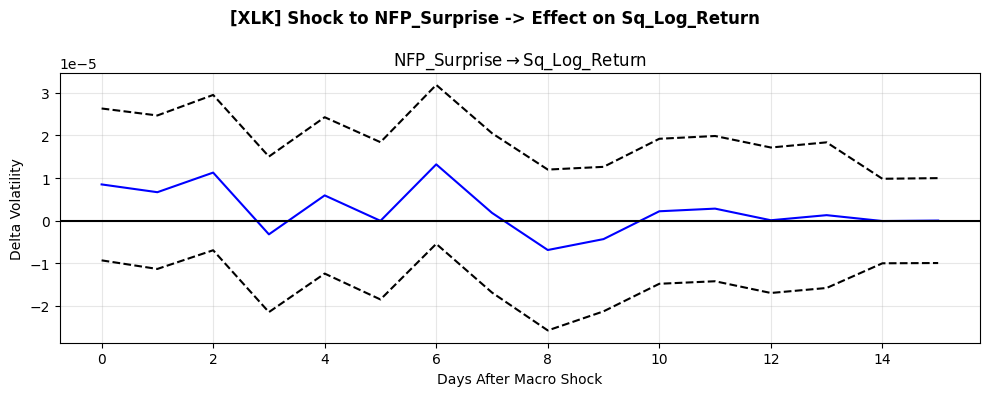

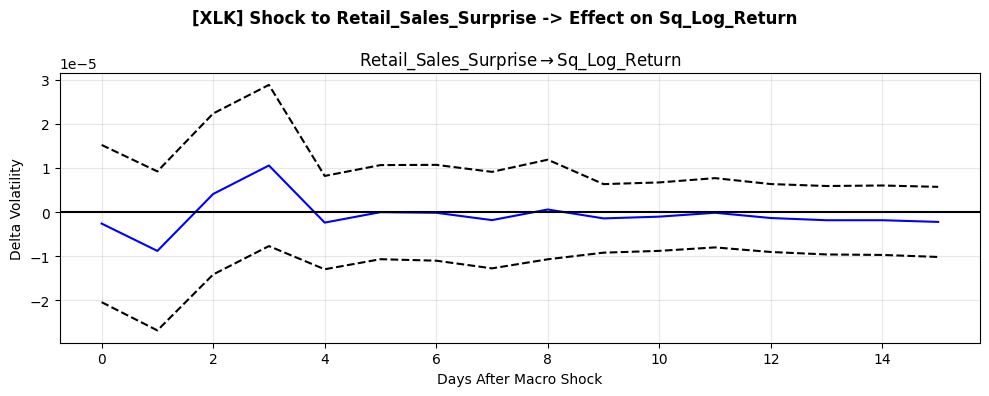

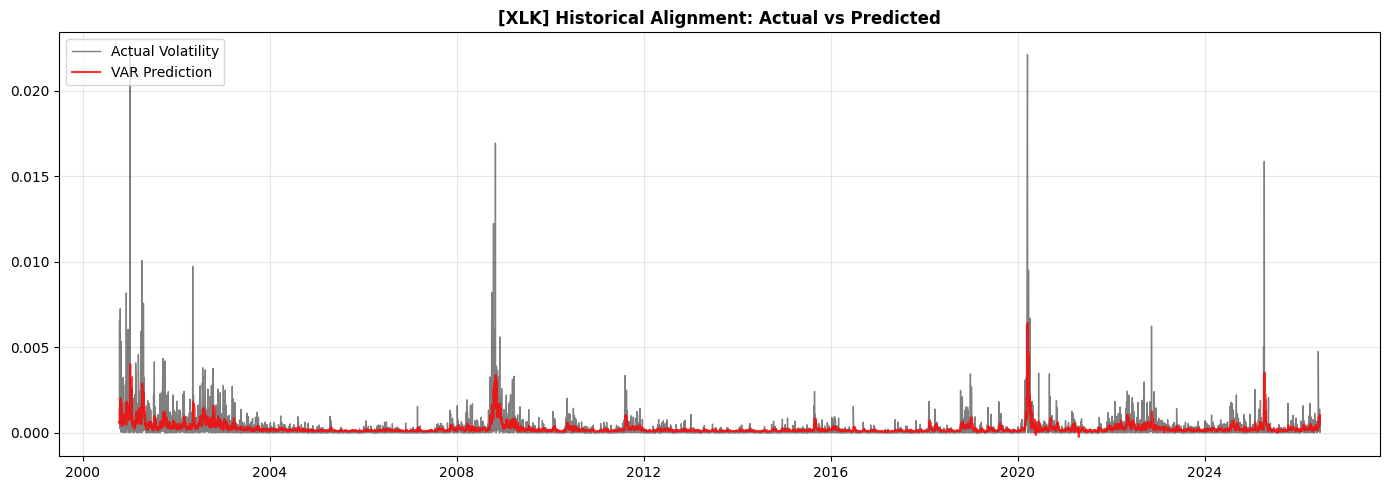


VISUAL DIAGNOSTICS: XLE


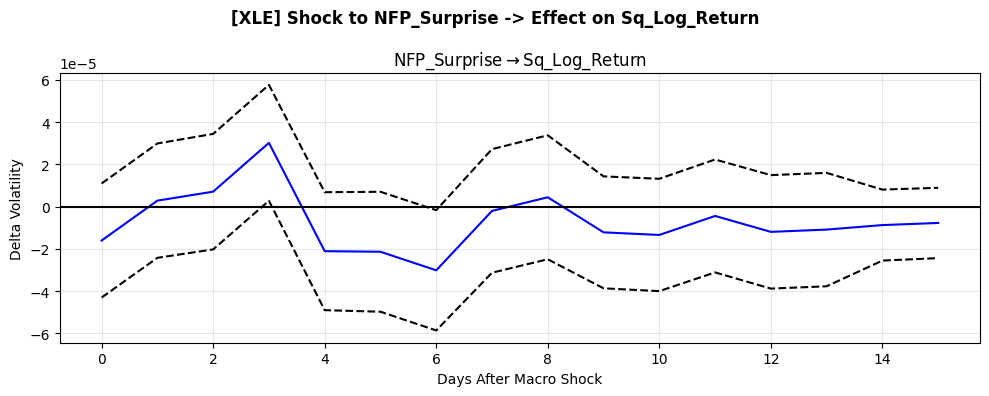

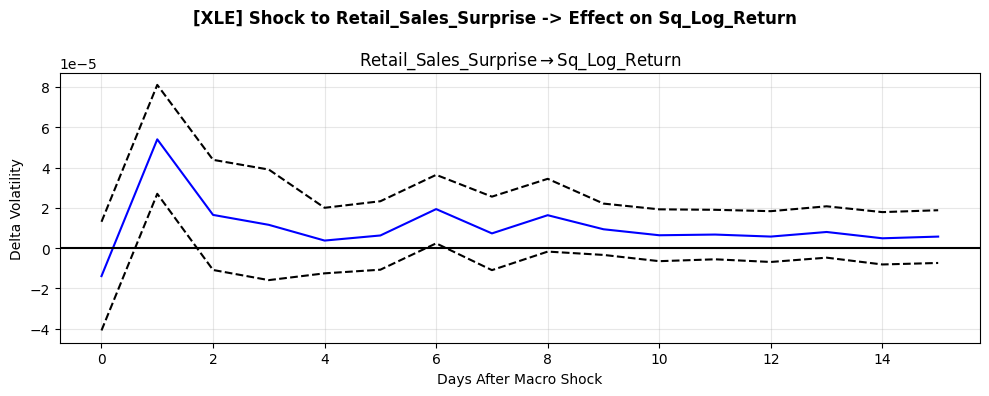

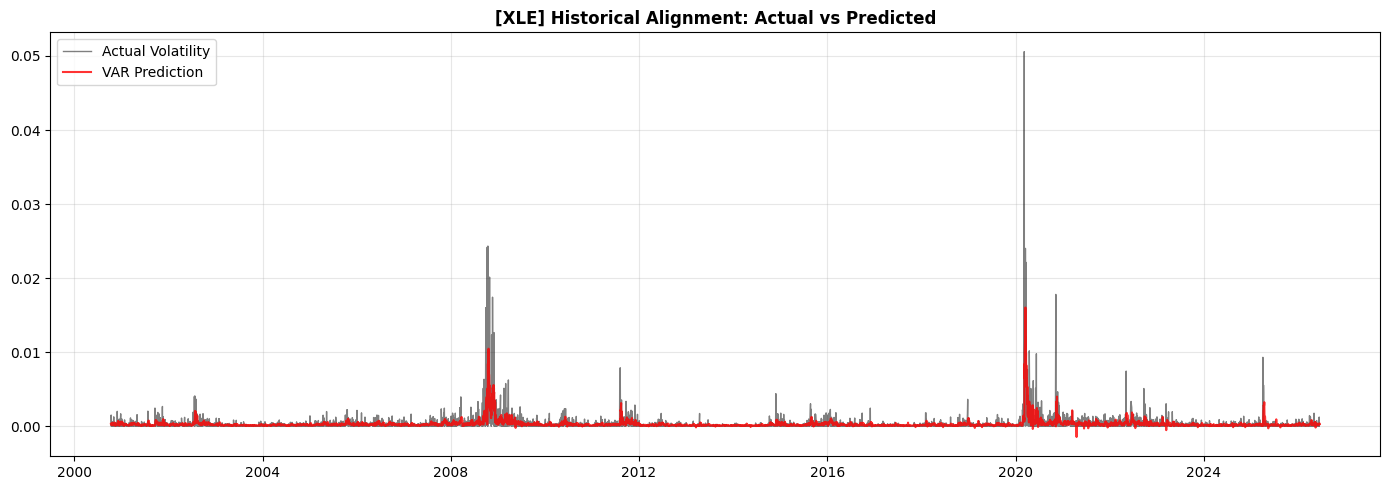


VISUAL DIAGNOSTICS: XLF


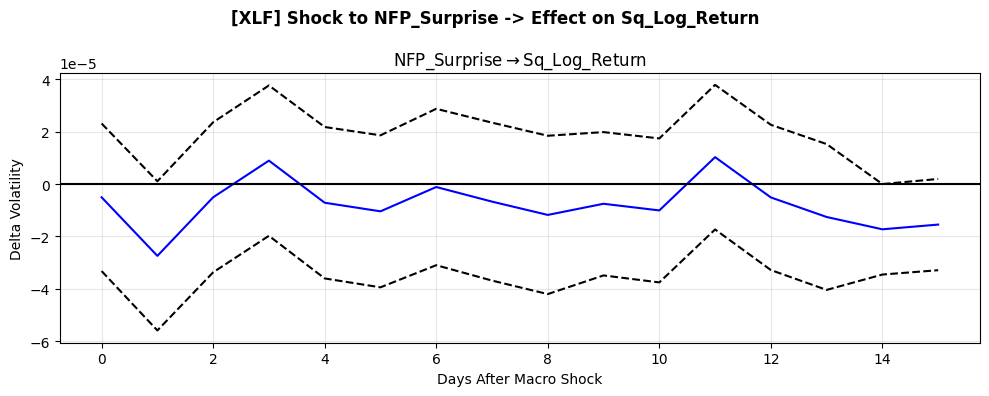

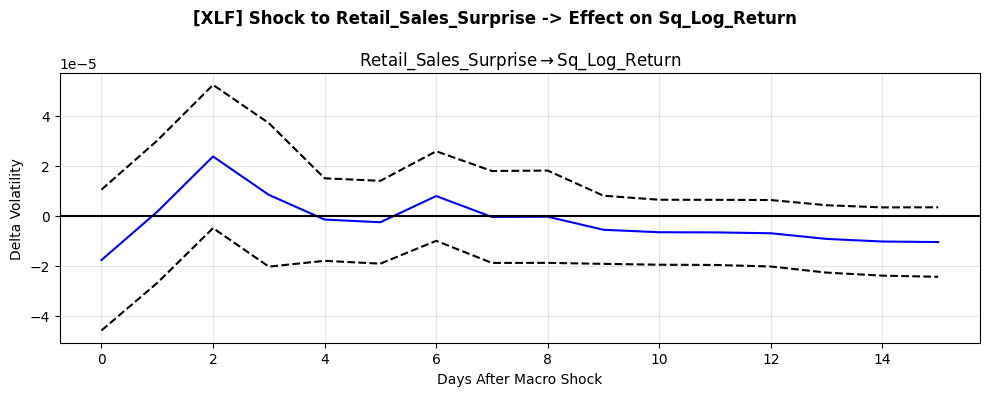

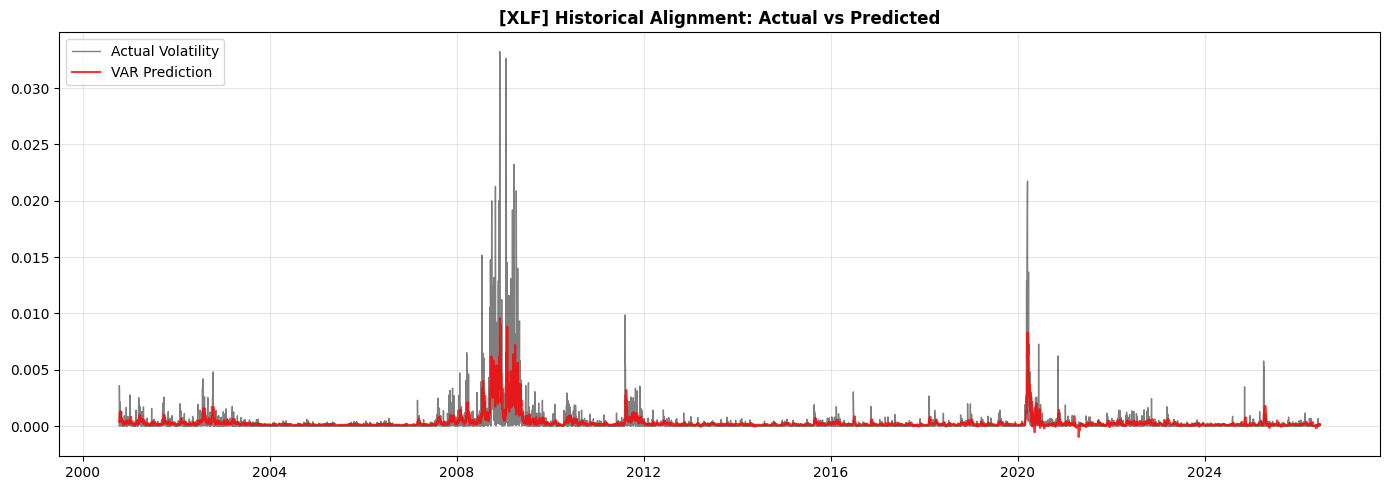


VISUAL DIAGNOSTICS: XLV


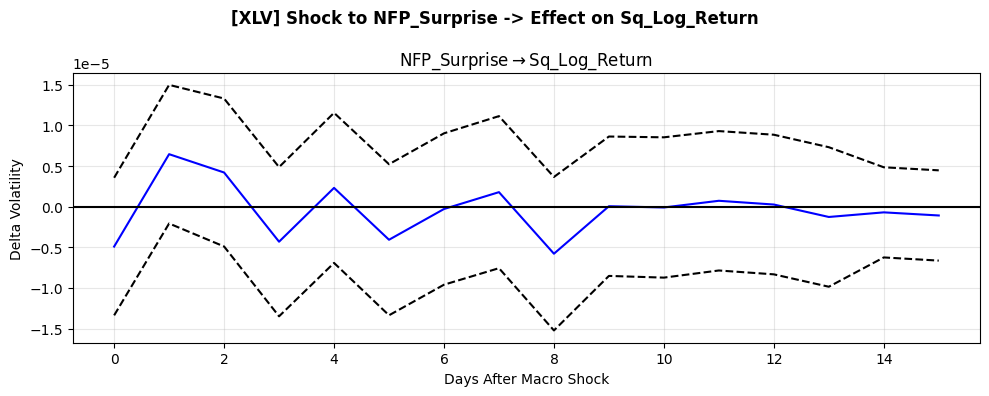

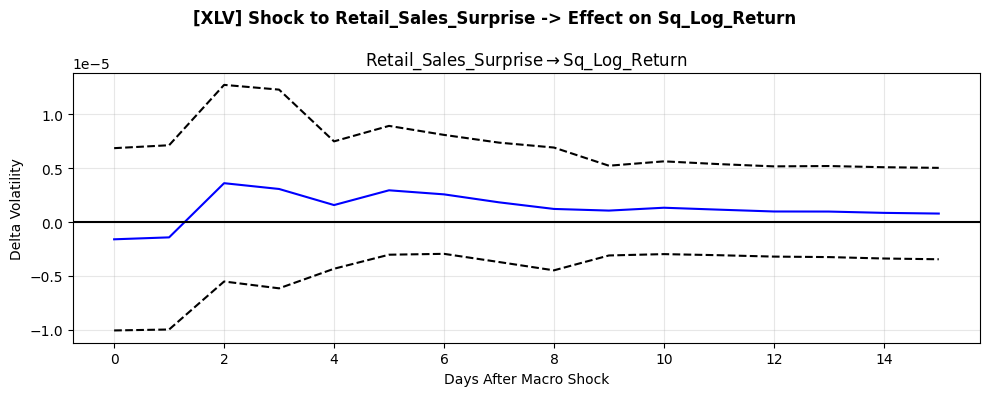

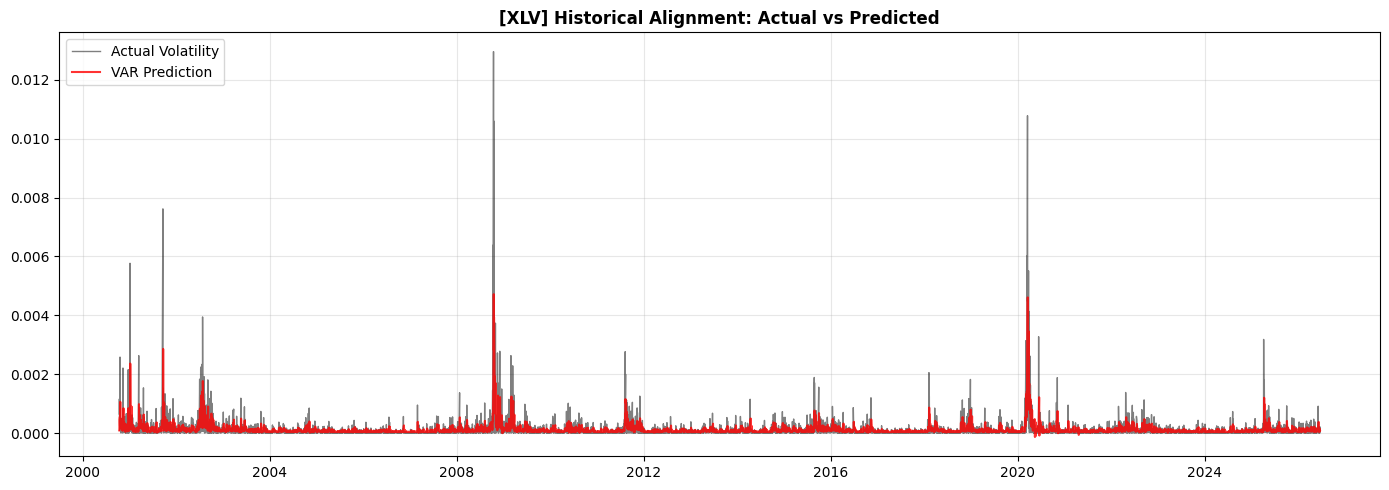

In [5]:
# 4. VISUALIZATIONS
for etf in config.TARGET_ETFS:
    print("\n" + "="*80)
    print(f"VISUAL DIAGNOSTICS: {etf}")
    print("="*80)
    
    results = sector_models[etf]
    var_data = sector_var_data[etf]
    
    econometrics.plot_irfs(results, var_data, sector_name=etf, irf_periods=15)
    econometrics.plot_historical_fit(results, var_data, sector_name=etf)
